# Fashion-MNIST Classification Project

This project builds a baseline neural network and three controlled experiments using TensorFlow/Keras.
The target is at least **88% test accuracy**, with the official test set reserved for one final
evaluation.

The final model is the validation-selected experiment with its weights restored from the lowest
validation-loss epoch. It is not retrained from scratch after selection because doing so would discard
the experimentally validated weights and learning-rate schedule.

## 1. Import Libraries


In [1]:
import time
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout, BatchNormalization, Activation
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


## 2. Load the Dataset


In [2]:
(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

print("Training images:", X_train_full.shape)
print("Training labels:", y_train_full.shape)
print("Test images:", X_test.shape)
print("Test labels:", y_test.shape)


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## 3. Data Preparation


In [3]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.10,
    random_state=SEED,
    stratify=y_train_full
)

X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# This normalized full set is used only after the best configuration is selected.
X_train_full_normalized = X_train_full.astype("float32") / 255.0

print("Training set:", X_train.shape)
print("Validation set:", X_val.shape)
print("Untouched test set:", X_test.shape)
print("Training pixel range:", X_train.min(), "to", X_train.max())

Training set: (54000, 28, 28)
Validation set: (6000, 28, 28)
Untouched test set: (10000, 28, 28)
Training pixel range: 0.0 to 1.0


The official test set is kept separate and is not used while comparing experiments. A stratified
90/10 split leaves 54,000 images for model learning and 6,000 for validation. Pixel values are
normalized to `[0, 1]`. After the configuration is selected from validation evidence, it is refitted
on all 60,000 original training images; the test set is still not used during this refit.

## 4. Explore the Images


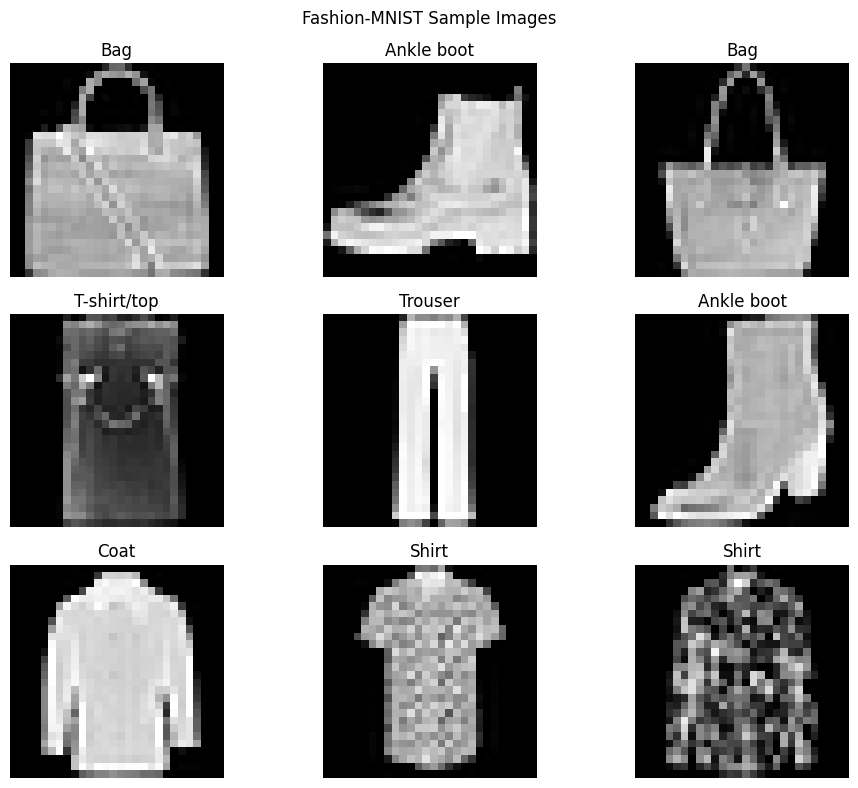

In [4]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(10, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.suptitle("Fashion-MNIST Sample Images")
plt.tight_layout()
plt.show()


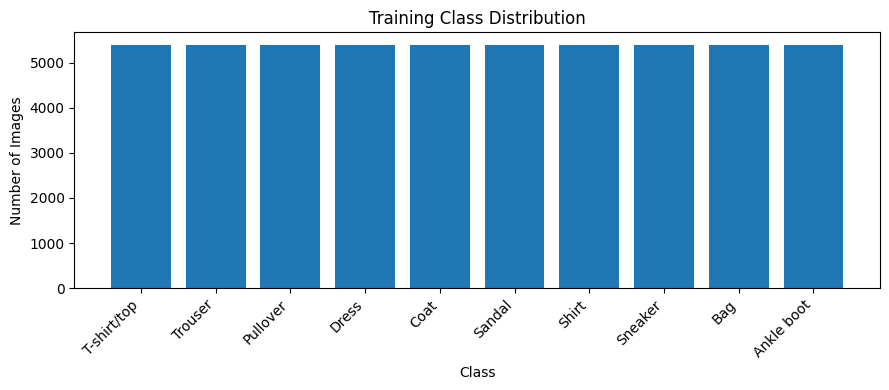

0    5400
1    5400
2    5400
3    5400
4    5400
5    5400
6    5400
7    5400
8    5400
9    5400
Name: count, dtype: int64


In [5]:
class_counts = pd.Series(y_train).value_counts().sort_index()

plt.figure(figsize=(9, 4))
plt.bar(class_names, class_counts.values)
plt.title("Training Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print(class_counts)


The classes have almost the same number of images. Therefore, class weighting is not required.


## 5. Helper Functions


In [6]:
EPOCHS = 30
BATCH_SIZE = 128
results = {}

def compile_model(model, learning_rate=0.001):
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

def make_callbacks():
    """Create fresh callbacks for one fair experimental run."""
    return [
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-5,
            verbose=1
        )
    ]

def train_model(name, model):
    tf.keras.utils.set_random_seed(SEED)
    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=make_callbacks(),
        verbose=1
    )

    training_time = time.time() - start_time
    val_loss, val_accuracy = model.evaluate(X_val, y_val, verbose=0)
    best_epoch = int(np.argmin(history.history["val_loss"]) + 1)
    train_accuracy_at_best = float(history.history["accuracy"][best_epoch - 1])

    results[name] = {
        "model": model,
        "history": history,
        "params": model.count_params(),
        "time": training_time,
        "epochs_run": len(history.history["loss"]),
        "best_epoch": best_epoch,
        "train_accuracy": train_accuracy_at_best,
        "val_accuracy": val_accuracy,
        "val_loss": val_loss,
        "gap": train_accuracy_at_best - val_accuracy
    }

    print(
        f"\n{name}: best_epoch={best_epoch}, val_accuracy={val_accuracy:.4f}, "
        f"val_loss={val_loss:.4f}, gap={train_accuracy_at_best - val_accuracy:.4f}"
    )
    return history

In [7]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Training")
    plt.plot(history.history["val_accuracy"], label="Validation")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Training")
    plt.plot(history.history["val_loss"], label="Validation")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

def show_effect(previous_name, current_name):
    previous = results[previous_name]
    current = results[current_name]

    print("Effect of the modification")
    print(f"Parameters: {previous['params']:,} -> {current['params']:,}")
    print(f"Training time: {previous['time']:.1f}s -> {current['time']:.1f}s")
    print(f"Training accuracy: {previous['train_accuracy']:.4f} -> {current['train_accuracy']:.4f}")
    print(f"Validation accuracy: {previous['val_accuracy']:.4f} -> {current['val_accuracy']:.4f}")
    print(f"Validation loss: {previous['val_loss']:.4f} -> {current['val_loss']:.4f}")
    print(f"Train-validation gap: {previous['gap']:.4f} -> {current['gap']:.4f}")
    print("Test performance: not checked yet; the test set is reserved for the final model.")


## 6. Baseline Model


In [8]:
baseline_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

compile_model(baseline_model)
baseline_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.8052 - loss: 0.5684 - val_accuracy: 0.8383 - val_loss: 0.4488 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8541 - loss: 0.4136 - val_accuracy: 0.8563 - val_loss: 0.3973 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8674 - loss: 0.3732 - val_accuracy: 0.8698 - val_loss: 0.3610 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8754 - loss: 0.3468 - val_accuracy: 0.8748 - val_loss: 0.3436 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8811 - loss: 0.3277 - val_accuracy: 0.8798 - val_loss: 0.3320 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.8862 - loss: 0.3111 - val_accuracy: 0.8820 - val_loss: 0.3208 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8902 - loss: 0.2978 -

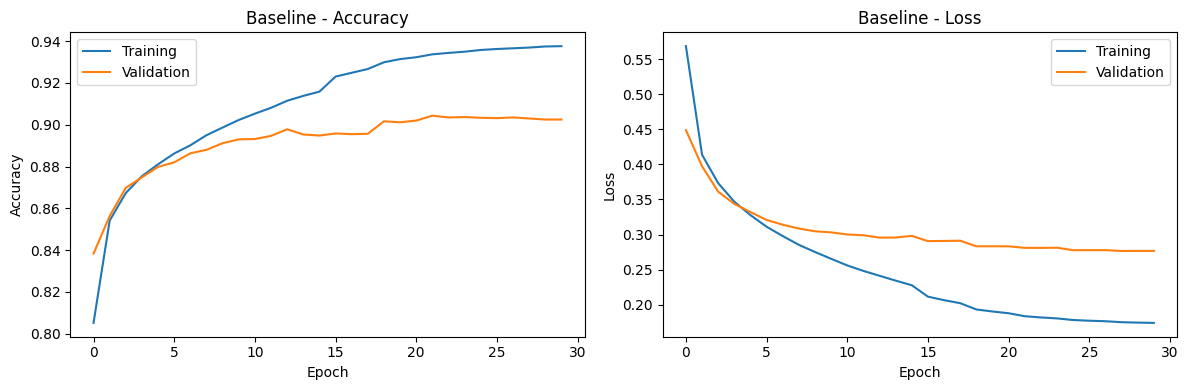

In [9]:
history_baseline = train_model("Baseline", baseline_model)
plot_history(history_baseline, "Baseline")


**Baseline result:** The baseline achieved 90.30% validation accuracy with a validation loss of 0.2766. It used 101,770 parameters, and the train-validation accuracy gap was 3.39%. This provided a strong reference for evaluating whether the following modifications improved validation performance and generalization.

## 7. Experiment 1: Increase Architecture Capacity

The only main change from the baseline is architecture capacity: the single 128-unit hidden layer is
replaced by two hidden layers with 256 and 128 units. This provides enough capacity to learn more
complex clothing patterns while remaining a Dense network.

In [10]:
experiment1_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(10, activation="softmax")
])

compile_model(experiment1_model, learning_rate=0.001)
experiment1_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_1 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 235,146 (918.54 KB)

 Trainable params: 235,146 (918.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.8161 - loss: 0.5203 - val_accuracy: 0.8580 - val_loss: 0.4046 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.8642 - loss: 0.3746 - val_accuracy: 0.8753 - val_loss: 0.3459 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8767 - loss: 0.3341 - val_accuracy: 0.8808 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8865 - loss: 0.3074 - val_accuracy: 0.8782 - val_loss: 0.3168 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8933 - loss: 0.2865 - val_accuracy: 0.8835 - val_loss: 0.3129 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8987 - loss: 0.2689 - val_accuracy: 0.8857 - val_loss: 0.3124 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9026 - loss: 0.2574 

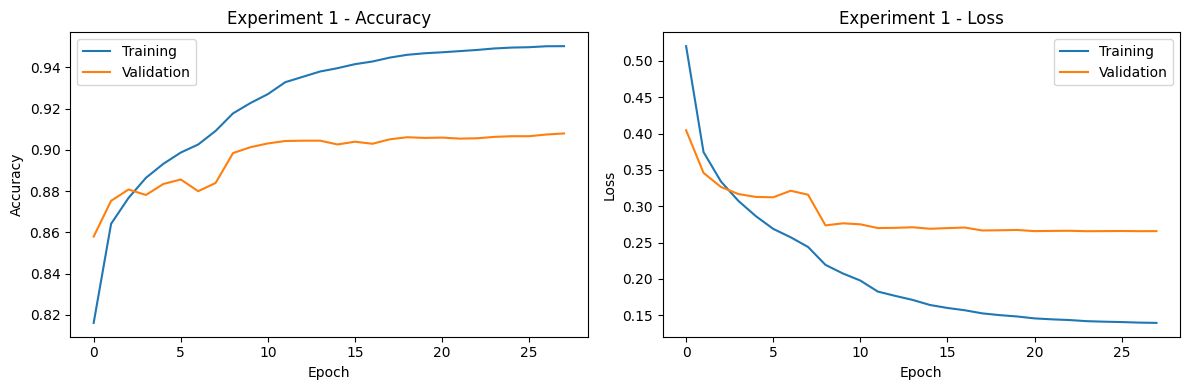

Effect of the modification
Parameters: 101,770 -> 235,146
Training time: 78.8s -> 109.9s
Training accuracy: 0.9369 -> 0.9492
Validation accuracy: 0.9030 -> 0.9063
Validation loss: 0.2766 -> 0.2657
Train-validation gap: 0.0339 -> 0.0429
Test performance: not checked yet; the test set is reserved for the final model.


In [11]:
history_exp1 = train_model("Experiment 1", experiment1_model)
plot_history(history_exp1, "Experiment 1")
show_effect("Baseline", "Experiment 1")


**Experiment 1 result:** Increasing the architecture from one 128-unit hidden layer to 256→128 units increased the parameter count from 101,770 to 235,146. Validation accuracy improved slightly from 90.30% to 90.63%, while validation loss decreased from 0.2766 to 0.2657. However, the train-validation gap increased from 3.39% to 4.29%, indicating that the additional capacity also increased overfitting.

## 8. Experiment 2: Add Batch Normalization and Dropout

This experiment keeps Experiment 1's 256→128 architecture and adds Batch Normalization plus moderate
Dropout. The Dropout rates are intentionally 0.20 rather than 0.30 because the earlier run showed
underfitting: training accuracy remained low and test accuracy reached only 87.68%.

In [12]:
experiment2_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.20),
    Dense(128, use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.20),
    Dense(10, activation="softmax")
])

compile_model(experiment2_model, learning_rate=0.001)
experiment2_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       200,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,298 (923.04 KB)

 Trainable params: 235,530 (920.04 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8144 - loss: 0.5239 - val_accuracy: 0.8627 - val_loss: 0.3747 - learning_rate: 0.0010
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.8591 - loss: 0.3846 - val_accuracy: 0.8625 - val_loss: 0.3574 - learning_rate: 0.0010
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8742 - loss: 0.3447 - val_accuracy: 0.8800 - val_loss: 0.3266 - learning_rate: 0.0010
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8815 - loss: 0.3198 - val_accuracy: 0.8787 - val_loss: 0.3292 - learning_rate: 0.0010
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8891 - loss: 0.3004 - val_accuracy: 0.8815 - val_loss: 0.3219 - learning_rate: 0.0010
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8944 - loss: 0.2828 - val_accuracy: 0.8905 - val_loss: 0.3008 - learning_rate: 0.0010
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8997 - loss: 0.2

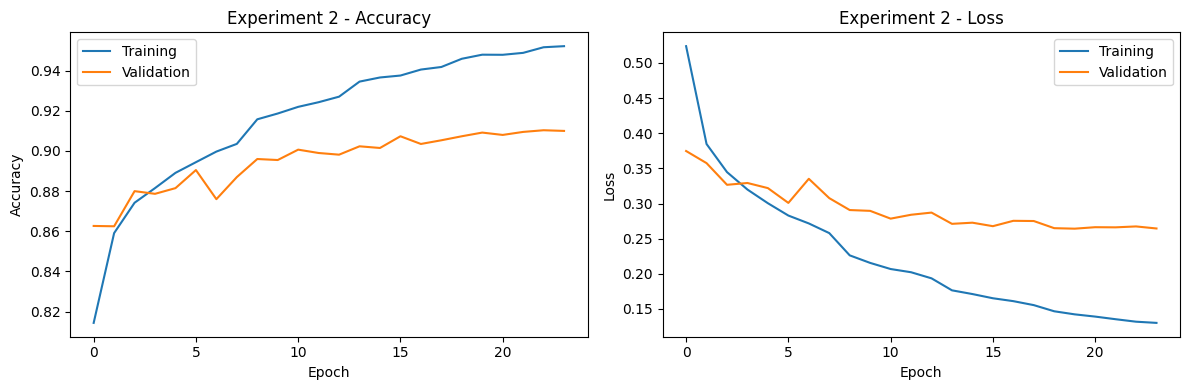

Effect of the modification
Parameters: 235,146 -> 236,298
Training time: 109.9s -> 121.1s
Training accuracy: 0.9492 -> 0.9480
Validation accuracy: 0.9063 -> 0.9092
Validation loss: 0.2657 -> 0.2642
Train-validation gap: 0.0429 -> 0.0388
Test performance: not checked yet; the test set is reserved for the final model.


In [13]:
history_exp2 = train_model("Experiment 2", experiment2_model)
plot_history(history_exp2, "Experiment 2")
show_effect("Experiment 1", "Experiment 2")


**Experiment 2 result:** Adding Batch Normalization and 20% Dropout produced the best validation performance. Validation accuracy increased to 90.92%, validation loss decreased to 0.2642, and the train-validation gap decreased from 4.29% to 3.88%. This shows that regularization improved generalization while retaining the benefit of the larger architecture.

## 9. Experiment 3: Lower the Learning Rate


In [14]:
experiment3_model = Sequential([
    keras.Input(shape=(28, 28)),
    Flatten(),
    Dense(256, use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.20),
    Dense(128, use_bias=False),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.20),
    Dense(10, activation="softmax")
])

compile_model(experiment3_model, learning_rate=0.0005)
experiment3_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_3 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       200,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,298 (923.04 KB)

 Trainable params: 235,530 (920.04 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.8025 - loss: 0.5730 - val_accuracy: 0.8503 - val_loss: 0.4076 - learning_rate: 5.0000e-04
Epoch 2/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8556 - loss: 0.4020 - val_accuracy: 0.8588 - val_loss: 0.3755 - learning_rate: 5.0000e-04
Epoch 3/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8706 - loss: 0.3596 - val_accuracy: 0.8748 - val_loss: 0.3389 - learning_rate: 5.0000e-04
Epoch 4/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8778 - loss: 0.3333 - val_accuracy: 0.8805 - val_loss: 0.3291 - learning_rate: 5.0000e-04
Epoch 5/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.8864 - loss: 0.3118 - val_accuracy: 0.8817 - val_loss: 0.3241 - learning_rate: 5.0000e-04
Epoch 6/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.8918 - loss: 0.2951 - val_accuracy: 0.8895 - val_loss: 0.2989 - learning_rate: 5.0000e-04
Epoch 7/30
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - acc

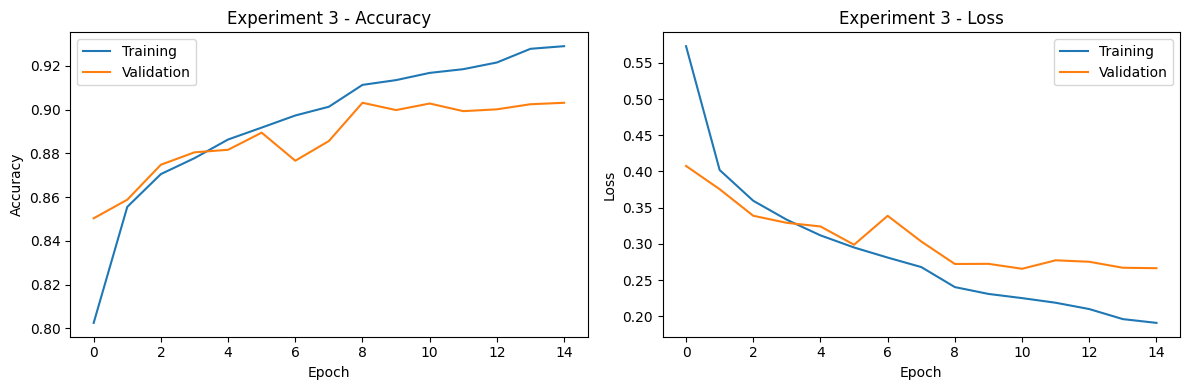

Effect of the modification
Parameters: 236,298 -> 236,298
Training time: 121.1s -> 73.8s
Training accuracy: 0.9480 -> 0.9168
Validation accuracy: 0.9092 -> 0.9028
Validation loss: 0.2642 -> 0.2657
Train-validation gap: 0.0388 -> 0.0140
Test performance: not checked yet; the test set is reserved for the final model.


In [15]:
history_exp3 = train_model("Experiment 3", experiment3_model)
plot_history(history_exp3, "Experiment 3")
show_effect("Experiment 2", "Experiment 3")


**Experiment 3 result:** Lowering Adam's initial learning rate from 0.001 to 0.0005 reduced the train-validation gap to 1.40%, but validation accuracy decreased to 90.28%. It also stopped earlier at epoch 11. Therefore, the lower learning rate controlled overfitting but did not outperform Experiment 2 in overall validation performance.

## 10. Experiment Comparison and Final Model


In [16]:
comparison_rows = []

for name, result in results.items():
    comparison_rows.append({
        "Model": name,
        "Parameters": result["params"],
        "Epochs Run": result["epochs_run"],
        "Best Epoch": result["best_epoch"],
        "Training Time (s)": round(result["time"], 1),
        "Training Accuracy at Best Epoch": round(result["train_accuracy"], 4),
        "Validation Accuracy": round(result["val_accuracy"], 4),
        "Validation Loss": round(result["val_loss"], 4),
        "Train-Val Gap": round(result["gap"], 4)
    })

comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["Validation Accuracy", "Validation Loss"],
    ascending=[False, True]
).reset_index(drop=True)

comparison_df.to_csv("comparison_table.csv", index=False)
comparison_df

,Model,Parameters,Epochs Run,Best Epoch,Training Time (s),Training Accuracy at Best Epoch,Validation Accuracy,Validation Loss,Train-Val Gap
0,Experiment 2,236298,24,20,121.1,0.9480,0.9092,0.2642,0.0388
1,Experiment 1,235146,28,24,109.9,0.9492,0.9063,0.2657,0.0429
2,Baseline,101770,30,28,78.8,0.9369,0.9030,0.2766,0.0339
3,Experiment 3,236298,15,11,73.8,0.9168,0.9028,0.2657,0.0140


In [17]:
best_name = comparison_df.iloc[0]["Model"]
selected_model = results[best_name]["model"]
selected_best_epoch = results[best_name]["best_epoch"]
selected_learning_rate = 0.0005 if best_name == "Experiment 3" else 0.001

print("Selected configuration:", best_name)
print("Best validation-loss epoch:", selected_best_epoch)
print("Selected initial learning rate:", selected_learning_rate)
print("Selection used validation evidence only; the test set has not been evaluated.")

Selected configuration: Experiment 2
Best validation-loss epoch: 20
Selected initial learning rate: 0.001
Selection used validation evidence only; the test set has not been evaluated.


**Model comparison:** Experiment 2 was selected as the final model because it achieved the highest validation accuracy of 90.92% and the lowest validation loss of 0.2642. Its 3.88% generalization gap was also smaller than the unregularized deeper model's 4.29% gap. The selection was made entirely from validation results without using test performance.

## 11. Keep the Validation-Selected Best Weights

Experiment 2 achieved the strongest validation result in this run: approximately 90.92% validation
accuracy. Its `EarlyStopping` callback restored the weights from epoch 20, the epoch with the lowest
validation loss. The previous notebook mistakenly cloned and retrained this model from scratch,
discarding those validated weights and the learning-rate reductions. The corrected workflow uses the
selected model directly.

In [18]:
# Keep the model selected using validation evidence and its restored best weights.
final_model = selected_model

final_val_loss, final_val_accuracy = final_model.evaluate(X_val, y_val, verbose=0)

print("Final model:", best_name)
print("Restored best epoch:", selected_best_epoch)
print(f"Validation accuracy: {final_val_accuracy:.4f}")
print(f"Validation loss: {final_val_loss:.4f}")
print("No retraining was performed after model selection.")
print("The official test set has not yet been evaluated in this workflow.")

Final model: Experiment 2
Restored best epoch: 20
Validation accuracy: 0.9092
Validation loss: 0.2642
No retraining was performed after model selection.
The official test set has not yet been evaluated in this workflow.


## 12. Final Test Evaluation

The official test set is evaluated once using the validation-selected model and its restored best
weights. All architecture, regularization, optimizer, and stopping decisions were made from training
and validation evidence.

In [19]:
y_prob = final_model.predict(X_test, verbose=0)
y_pred = np.argmax(y_prob, axis=1)

test_accuracy = accuracy_score(y_test, y_pred)
test_precision = precision_score(y_test, y_pred, average="macro")
test_recall = recall_score(y_test, y_pred, average="macro")
test_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Test Accuracy:  {test_accuracy:.4f}")
print(f"Macro Precision: {test_precision:.4f}")
print(f"Macro Recall:    {test_recall:.4f}")
print(f"Macro F1-score:  {test_f1:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))


if test_accuracy >= 0.88:
    print("\nTarget achieved: test accuracy is at least 88%.")
else:
    print("\nTarget not achieved in this run. Do not tune on the test result; report it honestly.")

Test Accuracy:  0.8976
Macro Precision: 0.8985
Macro Recall:    0.8976
Macro F1-score:  0.8979

              precision    recall  f1-score   support

 T-shirt/top     0.8582    0.8230    0.8402      1000
     Trouser     0.9929    0.9790    0.9859      1000
    Pullover     0.8192    0.8200    0.8196      1000
       Dress     0.8863    0.9200    0.9028      1000
        Coat     0.8438    0.8210    0.8322      1000
      Sandal     0.9817    0.9670    0.9743      1000
       Shirt     0.7039    0.7370    0.7201      1000
     Sneaker     0.9456    0.9740    0.9596      1000
         Bag     0.9818    0.9710    0.9764      1000
  Ankle boot     0.9718    0.9640    0.9679      1000

    accuracy                         0.8976     10000
   macro avg     0.8985    0.8976    0.8979     10000
weighted avg     0.8985    0.8976    0.8979     10000


Target achieved: test accuracy is at least 88%.


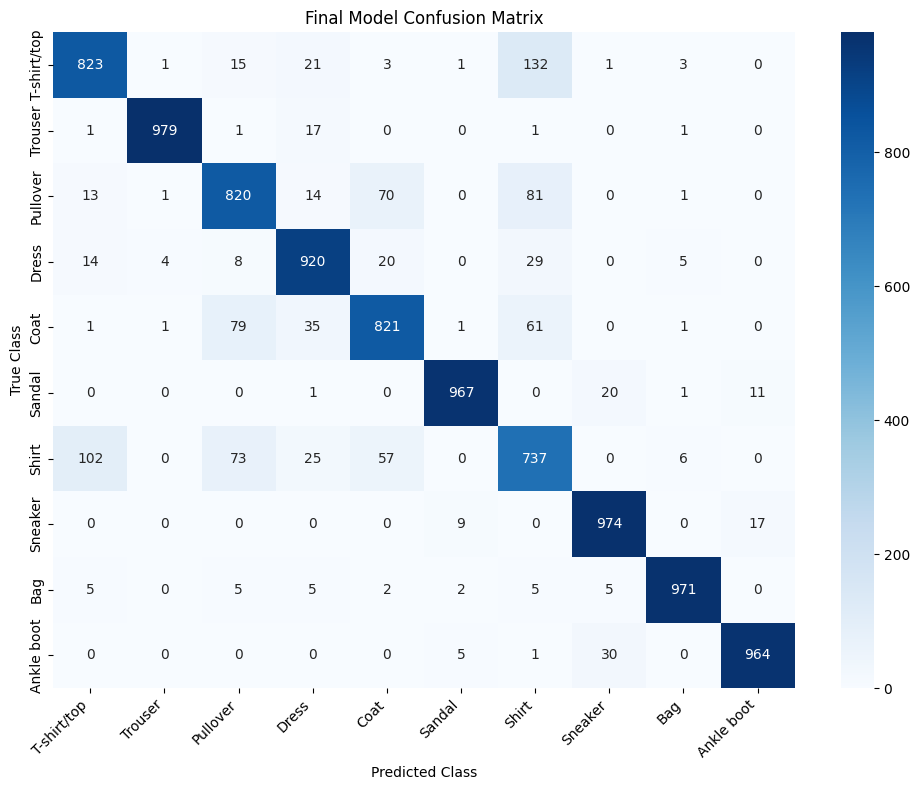

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)
plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## 13. Analyze Five Incorrect Predictions

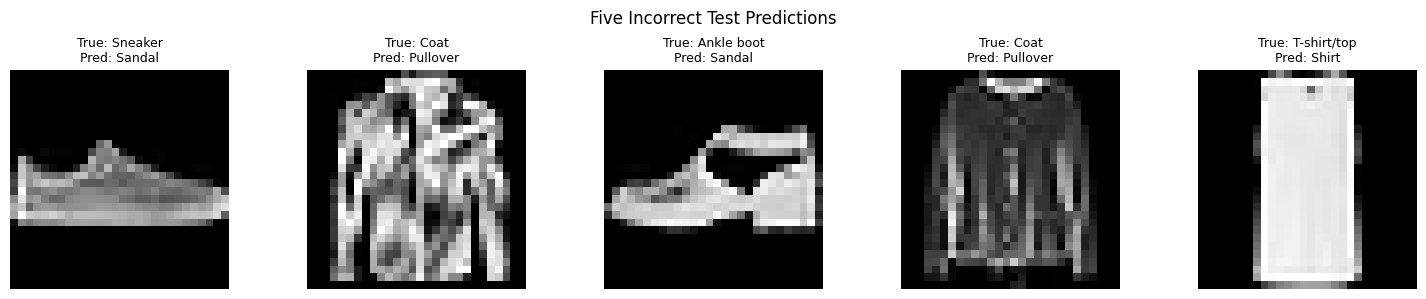

,True Class,Predicted Class,Confidence,Short Explanation
0,Sneaker,Sandal,0.6591,The footwear outline looks similar at low reso...
1,Coat,Pullover,0.9935,The two upper-body classes have a similar shape.
2,Ankle boot,Sandal,0.9989,The footwear outline looks similar at low reso...
3,Coat,Pullover,0.8004,The two upper-body classes have a similar shape.
4,T-shirt/top,Shirt,0.5226,The two upper-body classes have a similar shape.


In [21]:
wrong_indices = np.where(y_pred != y_test)[0][:5]
analysis = []

plt.figure(figsize=(15, 3))
for position, index in enumerate(wrong_indices):
    true_class = class_names[y_test[index]]
    predicted_class = class_names[y_pred[index]]
    confidence = y_prob[index][y_pred[index]]

    if true_class in ["T-shirt/top", "Shirt", "Pullover", "Coat"] and predicted_class in ["T-shirt/top", "Shirt", "Pullover", "Coat"]:
        reason = "The two upper-body classes have a similar shape."
    elif true_class in ["Sandal", "Sneaker", "Ankle boot"] and predicted_class in ["Sandal", "Sneaker", "Ankle boot"]:
        reason = "The footwear outline looks similar at low resolution."
    else:
        reason = "The image shape or shading is not very clear."

    analysis.append({
        "True Class": true_class,
        "Predicted Class": predicted_class,
        "Confidence": round(float(confidence), 4),
        "Short Explanation": reason
    })

    plt.subplot(1, 5, position + 1)
    plt.imshow(X_test[index], cmap="gray")
    plt.title(f"True: {true_class}\nPred: {predicted_class}", fontsize=9)
    plt.axis("off")

plt.suptitle("Five Incorrect Test Predictions")
plt.tight_layout()
plt.show()

pd.DataFrame(analysis)


## 14. Save the Model and Show Its Architecture

Model saved as best_model.keras


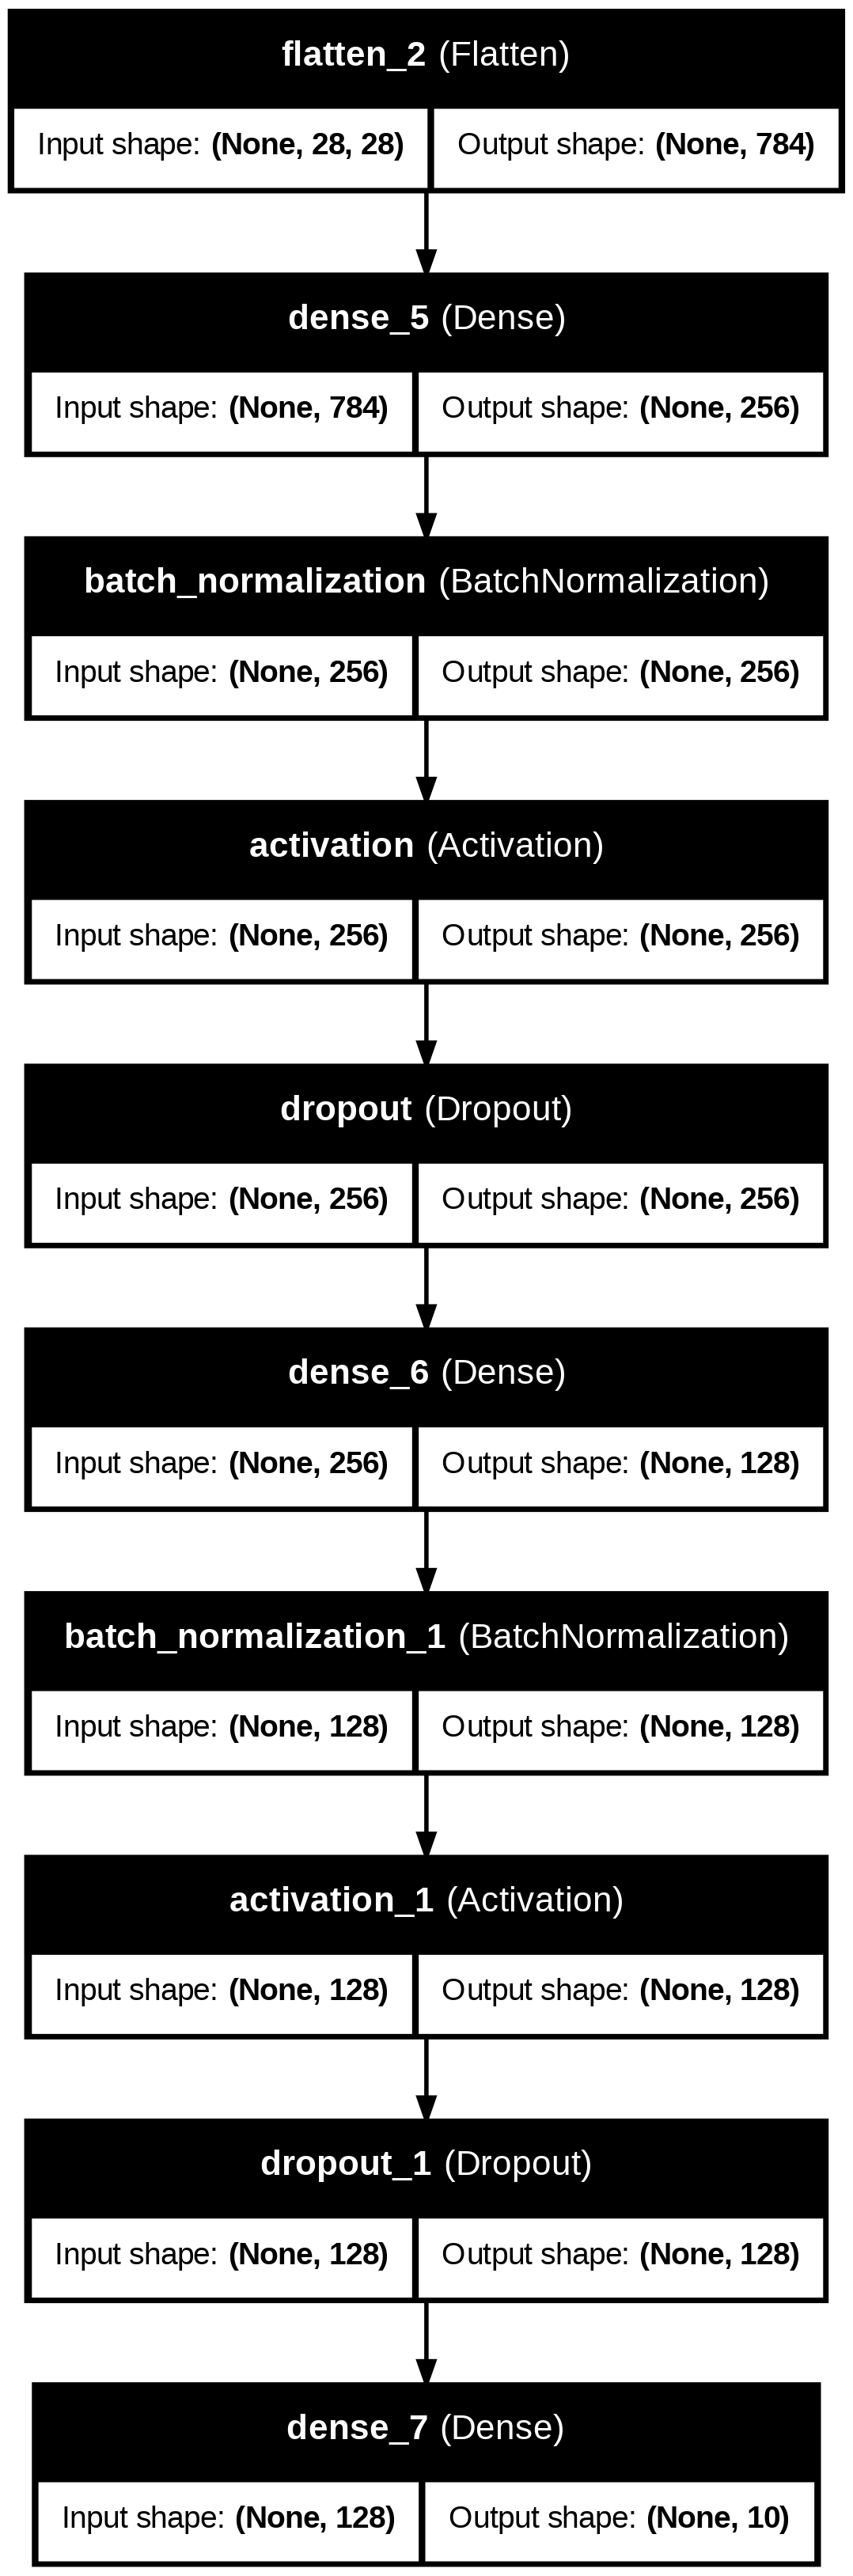

In [22]:
final_model.save("best_model.keras")
print("Model saved as best_model.keras")

keras.utils.plot_model(
    final_model,
    to_file="final_model_architecture.png",
    show_shapes=True,
    show_layer_names=True
)


## 15. Inference Function

In [23]:
def predict_image(image):
    image = np.asarray(image, dtype="float32")

    if image.shape != (28, 28):
        raise ValueError("The image must have shape (28, 28).")

    if image.max() > 1:
        image = image / 255.0

    probabilities = final_model.predict(image.reshape(1, 28, 28), verbose=0)[0]
    predicted_index = np.argmax(probabilities)

    return class_names[predicted_index], float(probabilities[predicted_index])

predicted_class, confidence = predict_image(X_test[0])
print("Predicted class:", predicted_class)
print(f"Confidence: {confidence:.2%}")


Predicted class: Ankle boot
Confidence: 99.98%


## 16. Conclusion

This project developed and compared a baseline neural network and three controlled experiments for Fashion-MNIST classification. The baseline achieved 90.30% validation accuracy. Increasing the network capacity improved validation accuracy to 90.63%, but it also increased the train-validation gap. Adding Batch Normalization and 20% Dropout produced the strongest result, reaching 90.92% validation accuracy with a validation loss of 0.2642.

Experiment 2 was selected as the final model using validation results only. On the unseen test set, it achieved 89.76% accuracy, 89.85% macro precision, 89.76% macro recall, and 89.79% macro F1-score. Therefore, the model successfully exceeded the required 88% test-accuracy target.

The model showed some overfitting because its training accuracy at the best epoch was 94.80%, compared with 90.92% validation accuracy, creating a 3.88% gap. However, Batch Normalization, Dropout, early stopping, and learning-rate reduction helped control this gap.

The most difficult class was Shirt, followed by Pullover, Coat, and T-shirt/top. These garments have similar silhouettes, and important distinguishing details are difficult to preserve in 28×28 grayscale images. With more time, I would test a compact convolutional neural network because it can preserve spatial relationships and may distinguish these visually similar classes more effectively.